In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [2]:
spy = pd.read_csv('data/SPY_features.csv', parse_dates=['date'], index_col='date').sort_index()
spy.head()

,adj_close,close,high,low,open,volume,daily_return,weekly_return,ma_7,ma_21,...,lag_return_5,month,quarter,season_num,season,is_earnings_week,vix,is_major_event,target_direction,target_return
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,170.125015,205.429993,206.880005,204.179993,206.380005,121465900,-0.000535,-0.011262,171.691376,169.676133,...,0.000096,1,1,0,Winter,0,17.790001,0,0,-0.005744
2015-01-05,167.052658,201.720001,204.369995,201.350006,204.169998,169632600,-0.018059,-0.032239,170.977999,169.477819,...,0.003225,1,1,0,Winter,0,19.920000,0,0,0.004610
2015-01-06,165.479141,199.820007,202.720001,198.860001,202.089996,209151400,-0.009419,-0.042641,170.037469,169.213594,...,0.001344,1,1,0,Winter,0,21.120001,0,1,0.011310
2015-01-07,167.541260,202.309998,202.720001,200.880005,201.419998,125346700,0.012462,-0.025481,169.312267,169.034233,...,-0.005366,1,1,0,Winter,0,19.309999,0,1,-0.007167
2015-01-08,170.514206,205.899994,206.160004,203.990005,204.009995,147217800,0.017745,0.001751,168.978638,169.050955,...,-0.009923,1,1,0,Winter,0,17.010000,0,0,-0.033414


In [3]:
FEATURES = [
    'daily_return', 'weekly_return', 'ma_cross', 'dist_from_ma21', 'daily_range',
    'rsi_14', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20',
    'volume_change', 'volume_ratio',
    'lag_return_1', 'lag_return_3', 'lag_return_5',
    'month', 'vix'
]
TARGET_CLS = 'target_direction'

spy_cls = spy[FEATURES + [TARGET_CLS]].dropna().copy()
print(spy_cls.shape)

(2515, 18)


In [4]:
def walk_forward_splits(df, train_window, test_window=42, embargo=5):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + embargo + test_window <= n:
        train_idx = list(range(start, start + train_window))
        test_idx  = list(range(start + train_window + embargo,
                               start + train_window + embargo + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits

spy_folds = walk_forward_splits(spy_cls, train_window=189)
print("SPY folds:", len(spy_folds))

SPY folds: 55


In [5]:
# scale_pos_weight = count(DOWN) / count(UP) to handle class imbalance
neg = (spy_cls[TARGET_CLS] == 0).sum()
pos = (spy_cls[TARGET_CLS] == 1).sum()
scale_pos_weight = neg / pos
print(f'DOWN: {neg}, UP: {pos}, scale_pos_weight: {scale_pos_weight:.3f}')

DOWN: 1142, UP: 1373, scale_pos_weight: 0.832


In [6]:
fold_scores = []
spy_actual, spy_pred = [], []
feat_imp_list = []

for train_idx, test_idx in spy_folds:
    X_train = spy_cls.iloc[train_idx][FEATURES]
    y_train = spy_cls.iloc[train_idx][TARGET_CLS]
    X_test  = spy_cls.iloc[test_idx][FEATURES]
    y_test  = spy_cls.iloc[test_idx][TARGET_CLS]

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    y_p = xgb.predict(X_test)

    feat_imp_list.append(xgb.feature_importances_)

    cm = confusion_matrix(y_test, y_p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    fold_scores.append({
        'accuracy':    accuracy_score(y_test, y_p),
        'f1':          f1_score(y_test, y_p, zero_division=0),
        'precision':   precision_score(y_test, y_p, zero_division=0),
        'recall':      recall_score(y_test, y_p, zero_division=0),
        'specificity': spec
    })
    spy_actual.extend(y_test)
    spy_pred.extend(y_p)

results_df = pd.DataFrame(fold_scores)
print(classification_report(spy_actual, spy_pred, zero_division=0))
print(results_df.describe())

              precision    recall  f1-score   support

           0       0.45      0.47      0.46      1038
           1       0.55      0.54      0.54      1272

    accuracy                           0.51      2310
   macro avg       0.50      0.50      0.50      2310
weighted avg       0.51      0.51      0.51      2310

        accuracy         f1  precision     recall  specificity
count  55.000000  55.000000  55.000000  55.000000    55.000000
mean    0.506061   0.526739   0.559706   0.535726     0.470047
std     0.081482   0.121963   0.122872   0.189753     0.202624
min     0.333333   0.250000   0.280000   0.190476     0.117647
25%     0.452381   0.452273   0.476190   0.387879     0.348485
50%     0.500000   0.520000   0.562500   0.500000     0.470588
75%     0.547619   0.621912   0.638182   0.660256     0.605556
max     0.690476   0.754717   1.000000   0.923077     1.000000


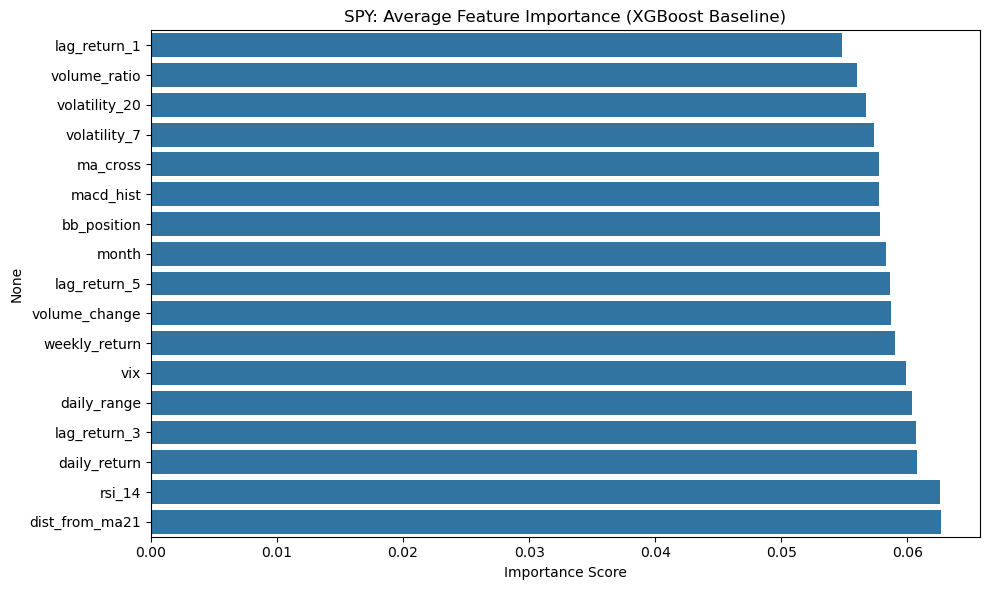

In [7]:
feat_imp = pd.DataFrame(feat_imp_list, columns=FEATURES).mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('SPY: Average Feature Importance (XGBoost Baseline)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [8]:
print(feat_imp.to_string())

lag_return_1      0.054794
volume_ratio      0.056029
volatility_20     0.056752
volatility_7      0.057350
ma_cross          0.057751
macd_hist         0.057758
bb_position       0.057866
month             0.058349
lag_return_5      0.058661
volume_change     0.058692
weekly_return     0.059024
vix               0.059914
daily_range       0.060359
lag_return_3      0.060717
daily_return      0.060737
rsi_14            0.062604
dist_from_ma21    0.062642


In [9]:
from itertools import product

n_estimators_values = [100, 200, 500]
max_depth_values    = [3, 4, 6]
learning_rate_values = [0.01, 0.05, 0.1]
subsample_values    = [0.7, 0.8, 1.0]

combos = list(product(n_estimators_values, max_depth_values, learning_rate_values, subsample_values))
print(f'Grid: {len(n_estimators_values)} n_est x {len(max_depth_values)} depth x {len(learning_rate_values)} lr x {len(subsample_values)} subsample = {len(combos)} combinations')
print(f'Folds per combo: {len(spy_folds)}')
print(f'Total XGB fits: {len(combos) * len(spy_folds)}')

Grid: 3 n_est x 3 depth x 3 lr x 3 subsample = 81 combinations
Folds per combo: 55
Total XGB fits: 4455


In [10]:
grid_results = []

for n_est, max_d, lr, subs in combos:
    fold_f1s, fold_accs, fold_precs, fold_recs, fold_specs = [], [], [], [], []

    for train_idx, test_idx in spy_folds:
        X_train = spy_cls.iloc[train_idx][FEATURES]
        y_train = spy_cls.iloc[train_idx][TARGET_CLS]
        X_test  = spy_cls.iloc[test_idx][FEATURES]
        y_test  = spy_cls.iloc[test_idx][TARGET_CLS]

        xgb = XGBClassifier(
            n_estimators=n_est,
            max_depth=max_d,
            learning_rate=lr,
            subsample=subs,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
        xgb.fit(X_train, y_train)
        y_p = xgb.predict(X_test)

        fold_f1s.append(f1_score(y_test, y_p, zero_division=0))
        fold_accs.append(accuracy_score(y_test, y_p))
        fold_precs.append(precision_score(y_test, y_p, zero_division=0))
        fold_recs.append(recall_score(y_test, y_p, zero_division=0))

        cm = confusion_matrix(y_test, y_p, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        fold_specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    grid_results.append({
        'n_estimators':  n_est,
        'max_depth':     max_d,
        'learning_rate': lr,
        'subsample':     subs,
        'f1':          np.mean(fold_f1s),
        'accuracy':    np.mean(fold_accs),
        'precision':   np.mean(fold_precs),
        'recall':      np.mean(fold_recs),
        'specificity': np.mean(fold_specs),
    })
    print(f'  n_est={n_est:>3}  depth={max_d}  lr={lr:.2f}  subs={subs:.1f}  '
          f'F1={np.mean(fold_f1s):.3f}  acc={np.mean(fold_accs):.3f}  '
          f'prec={np.mean(fold_precs):.3f}  rec={np.mean(fold_recs):.3f}  spec={np.mean(fold_specs):.3f}')

xgb_grid_df = pd.DataFrame(grid_results)

  n_est=100  depth=3  lr=0.01  subs=0.7  F1=0.496  acc=0.512  prec=0.548  rec=0.521  spec=0.491
  n_est=100  depth=3  lr=0.01  subs=0.8  F1=0.493  acc=0.513  prec=0.549  rec=0.520  spec=0.493
  n_est=100  depth=3  lr=0.01  subs=1.0  F1=0.489  acc=0.512  prec=0.558  rec=0.502  spec=0.506
  n_est=100  depth=3  lr=0.05  subs=0.7  F1=0.515  acc=0.507  prec=0.563  rec=0.525  spec=0.480
  n_est=100  depth=3  lr=0.05  subs=0.8  F1=0.527  acc=0.515  prec=0.565  rec=0.535  spec=0.485
  n_est=100  depth=3  lr=0.05  subs=1.0  F1=0.508  acc=0.507  prec=0.564  rec=0.510  spec=0.499
  n_est=100  depth=3  lr=0.10  subs=0.7  F1=0.520  acc=0.501  prec=0.551  rec=0.528  spec=0.469
  n_est=100  depth=3  lr=0.10  subs=0.8  F1=0.532  acc=0.513  prec=0.563  rec=0.543  spec=0.474
  n_est=100  depth=3  lr=0.10  subs=1.0  F1=0.526  acc=0.510  prec=0.556  rec=0.536  spec=0.479
  n_est=100  depth=4  lr=0.01  subs=0.7  F1=0.504  acc=0.510  prec=0.541  rec=0.530  spec=0.475
  n_est=100  depth=4  lr=0.01  subs=0.8 

In [11]:
print('Top 5 by F1:')
print(xgb_grid_df.sort_values('f1', ascending=False).head().to_string(index=False))

print('\nTop 5 by Accuracy:')
print(xgb_grid_df.sort_values('accuracy', ascending=False).head().to_string(index=False))

print('\nTop 5 by Precision:')
print(xgb_grid_df.sort_values('precision', ascending=False).head().to_string(index=False))

print('\nTop 5 by Specificity:')
print(xgb_grid_df.sort_values('specificity', ascending=False).head().to_string(index=False))

print('\nBaseline (n_est=100, depth=4, lr=0.1, subs=0.8):')
baseline = xgb_grid_df[
    (xgb_grid_df['n_estimators'] == 100) &
    (xgb_grid_df['max_depth'] == 4) &
    (xgb_grid_df['learning_rate'] == 0.1) &
    (xgb_grid_df['subsample'] == 0.8)
]
print(baseline.to_string(index=False))

Top 5 by F1:
 n_estimators  max_depth  learning_rate  subsample       f1  accuracy  precision   recall  specificity
          500          6           0.10        1.0 0.549238  0.520346   0.568953 0.564928     0.469317
          500          6           0.10        0.8 0.541603  0.512121   0.563849 0.554895     0.462415
          500          3           0.10        0.8 0.541542  0.512121   0.560993 0.555911     0.463031
          500          4           0.10        0.7 0.540851  0.512121   0.562796 0.555262     0.466542
          500          3           0.05        0.8 0.540598  0.516017   0.564516 0.551451     0.474763

Top 5 by Accuracy:
 n_estimators  max_depth  learning_rate  subsample       f1  accuracy  precision   recall  specificity
          500          6           0.10        1.0 0.549238  0.520346   0.568953 0.564928     0.469317
          500          4           0.01        0.8 0.536048  0.516450   0.568752 0.547176     0.474130
          500          3           0.05 